# 14 Entity Type Analysis

Purpose:
- isolate the entity-type story from the broader alignment notebooks
- quantify where human priors and model priors are aligned vs divergent
- produce export tables for the supplement

Primary questions:
1. Which entity types are most aligned between humans and model groups?
2. Do entity types differ in blind accuracy, semantic agreement, or bias signatures?
3. How do entity types degrade across control variants `C -> B -> A`?
4. Which entity types are most instruction-sensitive?


In [1]:
from __future__ import annotations

import csv
import math
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

BASE = Path('/home/david/Desktop/yuna/HPA')
sys.path.insert(0, str(BASE / 'analysis'))

from utils.constants import GROUP_COLORS, VARIANT_LABELS, VARIANT_ORDER

EXPORTS = BASE / 'analysis/session2/exports'
FIG_DIR = BASE / 'latex/AnonymousSubmission/LaTeX/figures'

sns.set_context('talk')
sns.set_style('whitegrid')

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)


In [2]:
human = pd.read_csv(EXPORTS / 'responses_human.csv')
model_blind = pd.read_csv(EXPORTS / 'responses_model_blind.csv')
model_inst = pd.read_csv(EXPORTS / 'responses_model_inst_blind.csv')
model_ctrl = pd.read_csv(EXPORTS / 'responses_model_control.csv')
pair_df = pd.read_parquet(EXPORTS / 'pair_cache.parquet')
combined = pd.read_csv(EXPORTS / 'combined_agreement.csv')

human.head(2)
q_meta = (human[['question_id', 'ent', 'op', 'question_en']]
    .drop_duplicates(subset=['question_id'])
)


,question_id,ent,op,variant,question_en,question_kr,gt,human_avg_acc,model_avg_acc,participant,accuracy,answer_kr,canonical_kr,response
0,1342072,other,ident,A,What kind of information does it look like it ...,그것에는 어떤 종류의 정보가 담겨 있는 것 같나요?,on planes | airplane info | transportation inf...,0.0,0.0,0S9EIHUY,0.0,색상 정보,색상 정보,color information
1,1342072,other,ident,A,What kind of information does it look like it ...,그것에는 어떤 종류의 정보가 담겨 있는 것 같나요?,on planes | airplane info | transportation inf...,0.0,0.0,0X4B4L3T,0.0,보물지도 위치,보물지도 위치,treasure map location


## Helpers

In [3]:
def pearson_safe(x, y):
    x = np.asarray(list(x), dtype=float)
    y = np.asarray(list(y), dtype=float)
    if len(x) < 2 or len(y) < 2:
        return np.nan
    if np.allclose(x, x.mean()) or np.allclose(y, y.mean()):
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def summarize_question_accuracy(df, who='model'):
    group_cols = ['question_id', 'ent', 'op', 'variant']
    if who == 'model':
        group_cols += ['model_group', 'model']
    out = (df.groupby(group_cols, dropna=False)['accuracy']
             .mean()
             .reset_index())
    out = out.rename(columns={'accuracy': f'{who}_acc'})
    return out


def export_csv(df, name):
    path = EXPORTS / name
    df.to_csv(path, index=False)
    print(f'saved: {path}')
    return path


def save_fig(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'saved figure: {path}')
    return path


def sort_entities(df, ent_col='ent'):
    order = ent_counts.sort_values('n_questions', ascending=False)['ent'].tolist()
    out = df.copy()
    out[ent_col] = pd.Categorical(out[ent_col], categories=order, ordered=True)
    return out.sort_values(ent_col)


## 1. Entity coverage

In [4]:
ent_counts = (human[human['variant'] == 'C'][['question_id', 'ent']]
              .drop_duplicates()['ent']
              .value_counts()
              .rename_axis('ent')
              .reset_index(name='n_questions'))
ent_counts

,ent,n_questions
0,object,27
1,person,26
2,animal,17
3,food,16
4,other,9
5,product,5
6,place,5
7,vehicle,4
8,text,4


## 2. Accuracy by entity type

In [5]:
human_q = summarize_question_accuracy(human, who='human')
blind_q = summarize_question_accuracy(model_blind, who='model')
inst_q = summarize_question_accuracy(model_inst, who='model')
ctrl_q = summarize_question_accuracy(model_ctrl, who='model')

human_ent_acc = (human_q.groupby(['ent', 'variant'], dropna=False)['human_acc']
                 .mean()
                 .reset_index())

model_ent_acc = (inst_q.groupby(['model_group', 'ent', 'variant'], dropna=False)['model_acc']
                 .mean()
                 .reset_index())

entity_accuracy_summary = (model_ent_acc
    .merge(human_ent_acc, on=['ent', 'variant'], how='left')
    .merge(ent_counts, on='ent', how='left')
    .sort_values(['variant', 'ent', 'model_group']))

entity_accuracy_summary.head(20)

,model_group,ent,variant,model_acc,human_acc,n_questions
0,VLM,animal,A,0.347339,0.312636,17
27,VLM backbone decoder,animal,A,0.437908,0.312636,17
54,standalone LLM,animal,A,0.152882,0.312636,17
81,standalone LLM (think),animal,A,0.135266,0.312636,17
3,VLM,food,A,0.410714,0.318866,16
30,VLM backbone decoder,food,A,0.381944,0.318866,16
57,standalone LLM,food,A,0.235772,0.318866,16
84,standalone LLM (think),food,A,0.182292,0.318866,16
6,VLM,object,A,0.396825,0.151578,27
33,VLM backbone decoder,object,A,0.193416,0.151578,27


## 3. Human-model difficulty correlation by entity type

In [6]:
merged_inst = inst_q.merge(
    human_q[['question_id', 'ent', 'op', 'variant', 'human_acc']],
    on=['question_id', 'ent', 'op', 'variant'],
    how='left'
)

corr_rows = []
for (model_group, ent, variant), sub in merged_inst.groupby(['model_group', 'ent', 'variant'], dropna=False):
    corr_rows.append({
        'model_group': model_group,
        'ent': ent,
        'variant': variant,
        'n_questions': sub['question_id'].nunique(),
        'pearson_r': pearson_safe(sub['human_acc'], sub['model_acc']),
        'human_mean_acc': sub['human_acc'].mean(),
        'model_mean_acc': sub['model_acc'].mean(),
    })

entity_corr = pd.DataFrame(corr_rows).sort_values(['variant', 'model_group', 'pearson_r'], ascending=[True, True, False])
entity_corr.head(30)

,model_group,ent,variant,n_questions,pearson_r,human_mean_acc,model_mean_acc
0,VLM,animal,A,17,0.891199,0.312636,0.347339
24,VLM,vehicle,A,4,0.881821,0.215278,0.345238
3,VLM,food,A,16,0.672335,0.318866,0.410714
9,VLM,other,A,9,0.570031,0.253086,0.386243
15,VLM,place,A,5,0.468628,0.401852,0.438095
12,VLM,person,A,26,0.392343,0.201923,0.377289
6,VLM,object,A,27,0.140541,0.151578,0.396825
18,VLM,product,A,5,-0.121602,0.138889,0.171429
21,VLM,text,A,4,NaN,0.000000,0.000000
51,VLM backbone decoder,vehicle,A,4,0.896156,0.215278,0.333333


## 4. Semantic agreement by entity type

Use HM pairwise agreement from the pair cache. This is the main evidence for
which model groups recover human priors at the meaning level.

In [7]:
hm_pairs = pair_df[(pair_df['pair_type'] == 'HM') & (pair_df['variant'].isin(VARIANT_ORDER))].copy()

entity_semantic = (hm_pairs.groupby(['subject_group_2', 'ent', 'variant'], dropna=False)
    .agg(
        sbert=('sbert_score_clip', 'mean'),
        simcse=('simcse_score_clip', 'mean'),
        bertscore=('bertscore_f1', 'mean'),
        exact=('exact_score', 'mean'),
        chrf=('chrf_score', 'mean'),
        n_pairs=('question_id', 'size'),
        n_questions=('question_id', 'nunique'),
    )
    .reset_index()
    .rename(columns={'subject_group_2': 'model_group'})
    .sort_values(['variant', 'ent', 'sbert'], ascending=[True, True, False]))

entity_semantic.head(30)

,model_group,ent,variant,sbert,simcse,bertscore,exact,chrf,n_pairs,n_questions
27,VLM backbone decoder,animal,A,0.469048,0.522967,0.955688,0.102623,0.149396,1296,12
0,VLM,animal,A,0.439128,0.503197,0.948708,0.095569,0.134680,3024,12
81,standalone LLM (think),animal,A,0.374538,0.489396,0.911586,0.065972,0.101722,1728,12
54,standalone LLM,animal,A,0.356441,0.478084,0.894420,0.056140,0.092801,3420,12
30,VLM backbone decoder,food,A,0.491228,0.551555,0.947562,0.084175,0.137132,1188,11
3,VLM,food,A,0.401426,0.478534,0.936865,0.038600,0.078192,2772,11
84,standalone LLM (think),food,A,0.388634,0.508109,0.900383,0.047348,0.082057,1584,11
57,standalone LLM,food,A,0.381279,0.507214,0.903688,0.045752,0.090512,3060,11
33,VLM backbone decoder,object,A,0.467473,0.540648,0.956943,0.079710,0.119173,2484,23
6,VLM,object,A,0.448027,0.530033,0.960047,0.058661,0.094046,5796,23


## 4a. Main-paper candidate: Pearson r by entity type

Compare `VLM` vs `VLM backbone decoder` on variant `C` only. This is the cleanest
entity-type view for the paper because it directly supports the main model-group claim.

saved figure: /home/david/Desktop/yuna/HPA/latex/AnonymousSubmission/LaTeX/figures/fig_entity_corr_groups.png


PosixPath('/home/david/Desktop/yuna/HPA/latex/AnonymousSubmission/LaTeX/figures/fig_entity_corr_groups.png')

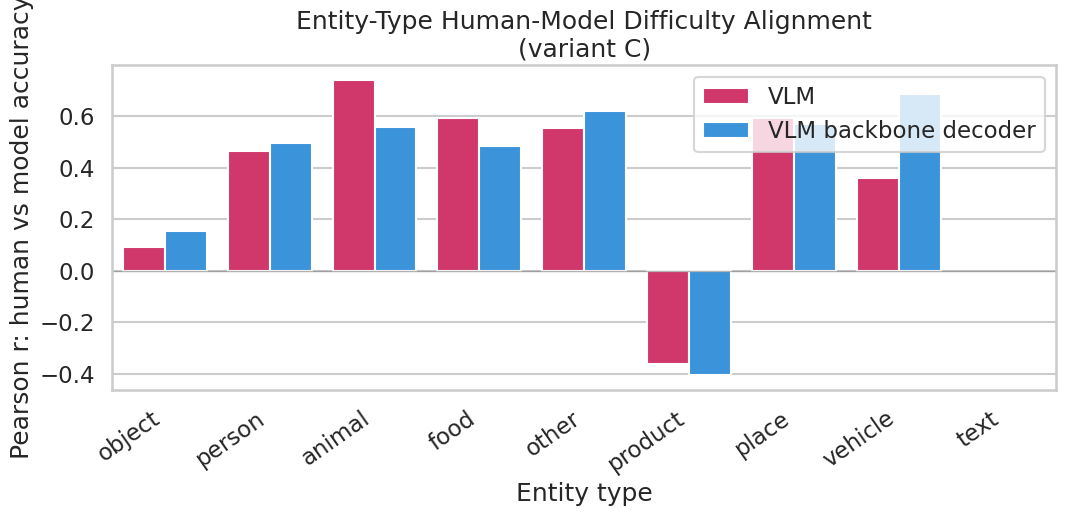

In [8]:
corr_plot = entity_corr[
    (entity_corr['variant'] == 'C')
    & (entity_corr['model_group'].isin(['VLM', 'VLM backbone decoder']))
    & (entity_corr['n_questions'] >= 3)
].copy()
corr_plot = sort_entities(corr_plot)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(
    data=corr_plot,
    x='ent', y='pearson_r', hue='model_group',
    palette={k: GROUP_COLORS[k] for k in ['VLM', 'VLM backbone decoder']},
    ax=ax
)
ax.axhline(0, color='gray', lw=1, alpha=0.6)
ax.set_xlabel('Entity type')
ax.set_ylabel('Pearson r: human vs model accuracy')
ax.set_title('Entity-Type Human-Model Difficulty Alignment\n(variant C)')
ax.legend(title=None, frameon=True, loc='upper right')
for tick in ax.get_xticklabels():
    tick.set_rotation(35)
    tick.set_horizontalalignment('right')
plt.tight_layout()
save_fig(fig, 'fig_entity_corr_groups.png')

## 4b. Main-paper candidate: semantic agreement by entity type

This focuses on `HM` SBERT agreement, which is the main semantic metric for
human-prior similarity.

saved figure: /home/david/Desktop/yuna/HPA/latex/AnonymousSubmission/LaTeX/figures/fig_entity_sbert_groups.png


PosixPath('/home/david/Desktop/yuna/HPA/latex/AnonymousSubmission/LaTeX/figures/fig_entity_sbert_groups.png')

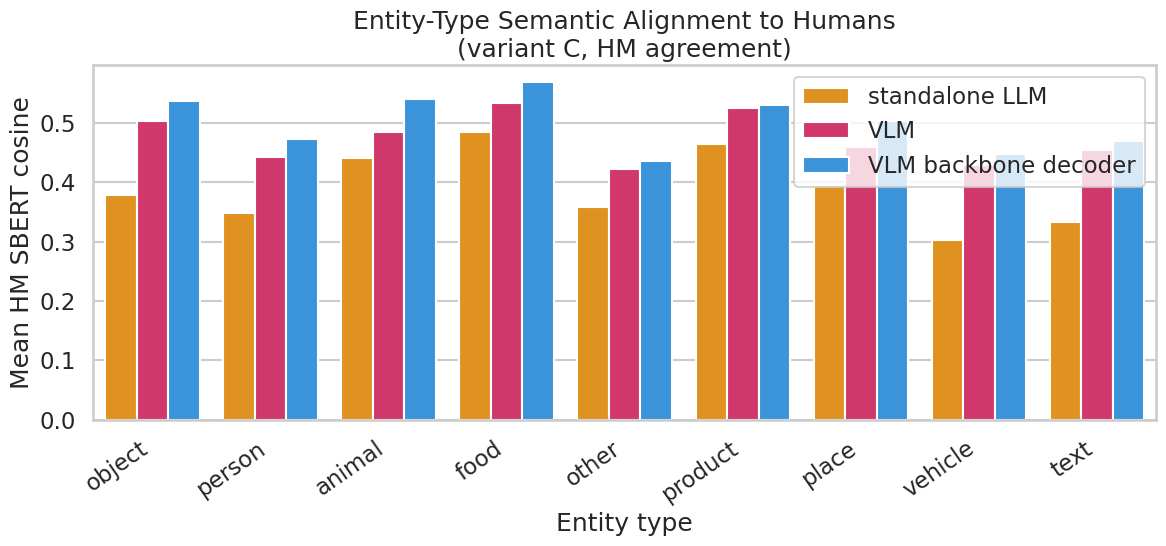

In [9]:
sem_plot = entity_semantic[
    (entity_semantic['variant'] == 'C')
    & (entity_semantic['model_group'].isin(['VLM', 'VLM backbone decoder', 'standalone LLM']))
    & (entity_semantic['n_questions'] >= 3)
].copy()
sem_plot = sort_entities(sem_plot)

fig, ax = plt.subplots(figsize=(12, 5.8))
sns.barplot(
    data=sem_plot,
    x='ent', y='sbert', hue='model_group',
    palette={k: GROUP_COLORS[k] for k in ['VLM', 'VLM backbone decoder', 'standalone LLM']},
    ax=ax
)
ax.set_xlabel('Entity type')
ax.set_ylabel('Mean HM SBERT cosine')
ax.set_title('Entity-Type Semantic Alignment to Humans\n(variant C, HM agreement)')
ax.legend(title=None, frameon=True, loc='upper right')
for tick in ax.get_xticklabels():
    tick.set_rotation(35)
    tick.set_horizontalalignment('right')
plt.tight_layout()
save_fig(fig, 'fig_entity_sbert_groups.png')

## 5. Control-variant degradation by entity type

In [10]:
ctrl_ent = (ctrl_q.groupby(['model_group', 'ent', 'variant'], dropna=False)['model_acc']
            .mean()
            .reset_index())

human_ctrl_ent = (human_q.groupby(['ent', 'variant'], dropna=False)['human_acc']
                  .mean()
                  .reset_index())

ctrl_pivot = ctrl_ent.pivot_table(index=['model_group', 'ent'], columns='variant', values='model_acc')
for col in ['A', 'B', 'C']:
    if col not in ctrl_pivot.columns:
        ctrl_pivot[col] = np.nan
ctrl_pivot = ctrl_pivot.reset_index()
ctrl_pivot['drop_C_to_A'] = ctrl_pivot['C'] - ctrl_pivot['A']
ctrl_pivot['drop_C_to_B'] = ctrl_pivot['C'] - ctrl_pivot['B']
ctrl_pivot.sort_values('drop_C_to_A', ascending=False).head(20)

variant,model_group,ent,A,B,C,drop_C_to_A,drop_C_to_B
6,VLM,product,0.171429,0.295238,0.409524,0.238095,0.114286
2,VLM,object,0.396825,0.477954,0.555556,0.158730,0.077601
5,VLM,place,0.438095,0.428571,0.590476,0.152381,0.161905
0,VLM,animal,0.347339,0.431373,0.459384,0.112045,0.028011
1,VLM,food,0.410714,0.479167,0.502976,0.092262,0.023810
7,VLM,text,0.000000,0.107143,0.037037,0.037037,-0.070106
4,VLM,person,0.377289,0.318600,0.399632,0.022342,0.081031
3,VLM,other,0.386243,0.423280,0.402116,0.015873,-0.021164
8,VLM,vehicle,0.345238,0.476190,0.333333,-0.011905,-0.142857


## 5a. Supplement figure: degradation heatmap by entity type

saved figure: /home/david/Desktop/yuna/HPA/latex/AnonymousSubmission/LaTeX/figures/fig_entity_degradation_heatmap.png


PosixPath('/home/david/Desktop/yuna/HPA/latex/AnonymousSubmission/LaTeX/figures/fig_entity_degradation_heatmap.png')

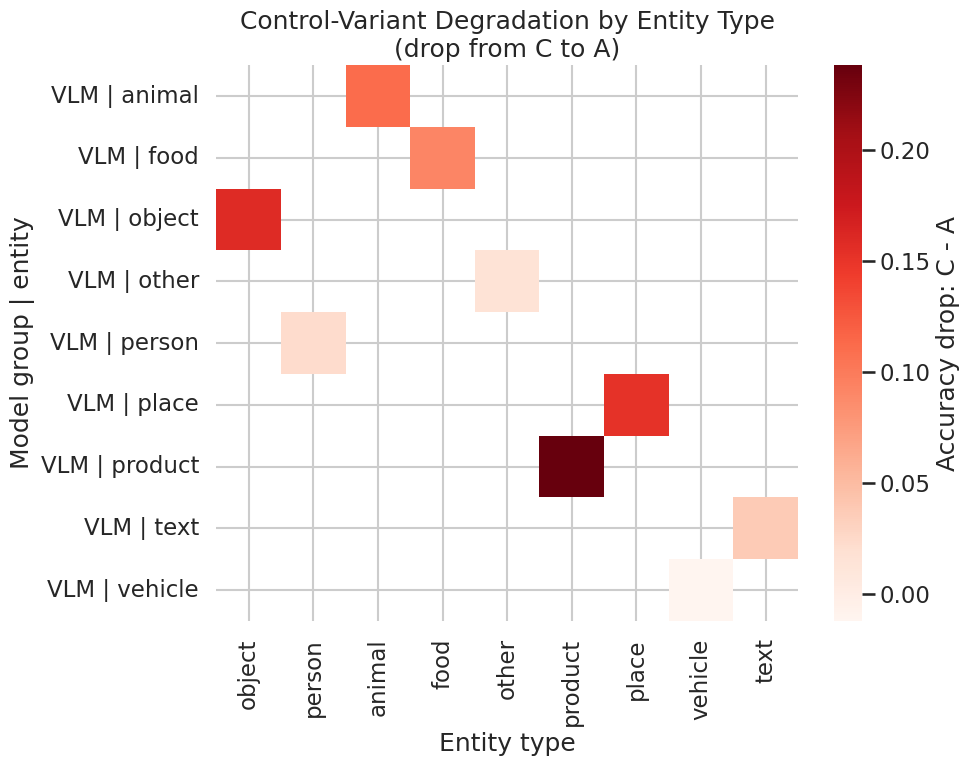

In [11]:
heat_deg = ctrl_pivot[ctrl_pivot['model_group'].isin(['VLM', 'VLM backbone decoder', 'standalone LLM'])].copy()
heat_deg = sort_entities(heat_deg)
heat_deg['row'] = heat_deg['model_group'] + ' | ' + heat_deg['ent'].astype(str)
heat_arr = heat_deg.pivot(index='row', columns='ent', values='drop_C_to_A')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heat_arr, cmap='Reds', annot=False, cbar_kws={'label': 'Accuracy drop: C - A'}, ax=ax)
ax.set_title('Control-Variant Degradation by Entity Type\n(drop from C to A)')
ax.set_xlabel('Entity type')
ax.set_ylabel('Model group | entity')
plt.tight_layout()
save_fig(fig, 'fig_entity_degradation_heatmap.png')

## 6. Instruction sensitivity by entity type

Accuracy deltas are near-zero in the current blind vs inst_blind exports, so
the main behavioral signal here is **response change rate** by entity type.


In [12]:
blind_ent_acc = (blind_q.groupby(['model_group', 'ent', 'variant'], dropna=False)['model_acc']
                 .mean()
                 .reset_index()
                 .rename(columns={'model_acc': 'blind_acc'}))

inst_ent_acc = (inst_q.groupby(['model_group', 'ent', 'variant'], dropna=False)['model_acc']
                .mean()
                .reset_index()
                .rename(columns={'model_acc': 'inst_acc'}))

entity_instruction = blind_ent_acc.merge(inst_ent_acc, on=['model_group', 'ent', 'variant'], how='outer')
entity_instruction['delta_inst_minus_blind'] = entity_instruction['inst_acc'] - entity_instruction['blind_acc']

resp_blind = model_blind[['question_id', 'ent', 'op', 'variant', 'model', 'model_group', 'response']].copy()
resp_inst = model_inst[['question_id', 'ent', 'op', 'variant', 'model', 'model_group', 'response']].copy()
resp_merged = resp_blind.merge(
    resp_inst,
    on=['question_id', 'ent', 'op', 'variant', 'model', 'model_group'],
    suffixes=('_blind', '_inst')
)
resp_merged['resp_blind_norm'] = resp_merged['response_blind'].fillna('').astype(str).str.strip().str.lower()
resp_merged['resp_inst_norm'] = resp_merged['response_inst'].fillna('').astype(str).str.strip().str.lower()
resp_merged['response_changed'] = (resp_merged['resp_blind_norm'] != resp_merged['resp_inst_norm']).astype(float)

entity_change = (resp_merged.groupby(['model_group', 'ent', 'variant'], dropna=False)['response_changed']
                 .mean()
                 .reset_index())

entity_instruction = entity_instruction.merge(entity_change, on=['model_group', 'ent', 'variant'], how='left')
entity_instruction.sort_values(['variant', 'response_changed'], ascending=[True, False]).head(20)


,model_group,ent,variant,blind_acc,inst_acc,delta_inst_minus_blind
0,VLM,animal,A,0.347339,0.347339,0.0
3,VLM,food,A,0.410714,0.410714,0.0
6,VLM,object,A,0.396825,0.396825,0.0
9,VLM,other,A,0.386243,0.386243,0.0
12,VLM,person,A,0.377289,0.377289,0.0
15,VLM,place,A,0.438095,0.438095,0.0
18,VLM,product,A,0.171429,0.171429,0.0
21,VLM,text,A,0.000000,0.000000,0.0
24,VLM,vehicle,A,0.345238,0.345238,0.0
27,VLM backbone decoder,animal,A,0.437908,0.437908,0.0


## 6a. Supplement figure: instruction sensitivity by entity type

Plot response change rate rather than accuracy delta, since that is the
informative behavioral effect in the current exports.


saved figure: /home/david/Desktop/yuna/HPA/latex/AnonymousSubmission/LaTeX/figures/fig_entity_instruction_delta.png


PosixPath('/home/david/Desktop/yuna/HPA/latex/AnonymousSubmission/LaTeX/figures/fig_entity_instruction_delta.png')

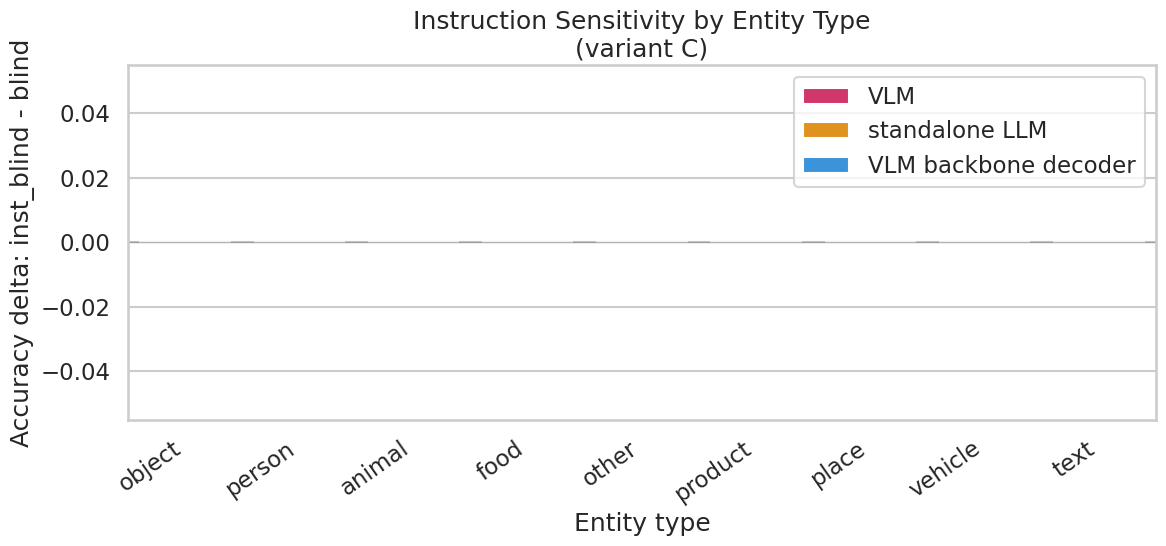

In [13]:
inst_plot = entity_instruction[
    (entity_instruction['variant'] == 'C')
    & (entity_instruction['model_group'].isin(['VLM', 'VLM backbone decoder', 'standalone LLM']))
].copy()
inst_plot = sort_entities(inst_plot)

fig, ax = plt.subplots(figsize=(12, 5.8))
sns.barplot(
    data=inst_plot,
    x='ent', y='response_changed', hue='model_group',
    palette={k: GROUP_COLORS[k] for k in ['VLM', 'VLM backbone decoder', 'standalone LLM']},
    ax=ax
)
ax.set_xlabel('Entity type')
ax.set_ylabel('Response change rate: blind vs inst_blind')
ax.set_title('Instruction Sensitivity by Entity Type\n(variant C, response change)')
ax.legend(title=None, frameon=True, loc='upper right')
for tick in ax.get_xticklabels():
    tick.set_rotation(35)
    tick.set_horizontalalignment('right')
plt.tight_layout()
save_fig(fig, 'fig_entity_instruction_delta.png')


## 7. Divergent example questions for the supplement

In [14]:
text_c = combined[(combined['answer_type'] == 'text') & (combined['variant'] == 'C')].copy()
text_c = text_c.merge(q_meta[['question_id', 'ent', 'op']], on='question_id', how='left')
text_c['gap_HH_HM'] = text_c['HH_sbert_score_clip'] - text_c['HM_sbert_score_clip']
entity_examples = (text_c[['question_id', 'question_en', 'ent', 'op', 'HH_sbert_score_clip', 'HM_sbert_score_clip', 'MM_sbert_score_clip', 'gap_HH_HM']]
                   .sort_values(['gap_HH_HM', 'ent'], ascending=[False, True]))
entity_examples.head(20)


KeyError: "['ent', 'op'] not in index"

## 8. Supplement exports

In [15]:
export_csv(entity_accuracy_summary, 'entity_accuracy_summary.csv')
export_csv(entity_corr, 'entity_difficulty_correlation.csv')
export_csv(entity_semantic, 'entity_semantic_alignment.csv')
export_csv(ctrl_pivot, 'entity_control_degradation.csv')
export_csv(entity_instruction, 'entity_instruction_sensitivity.csv')
export_csv(entity_examples.head(50), 'entity_divergent_examples.csv')

saved: /home/david/Desktop/yuna/HPA/analysis/session2/exports/entity_accuracy_summary.csv
saved: /home/david/Desktop/yuna/HPA/analysis/session2/exports/entity_difficulty_correlation.csv
saved: /home/david/Desktop/yuna/HPA/analysis/session2/exports/entity_semantic_alignment.csv
saved: /home/david/Desktop/yuna/HPA/analysis/session2/exports/entity_control_degradation.csv
saved: /home/david/Desktop/yuna/HPA/analysis/session2/exports/entity_instruction_sensitivity.csv


NameError: name 'entity_examples' is not defined

## 9. Suggested supplement figures

Main-paper candidates:
- `fig_entity_corr_groups.png`: Pearson `r` by entity type for `VLM` vs `VLM backbone decoder`
- `fig_entity_sbert_groups.png`: SBERT HM agreement by entity type across model groups

Supplement candidates:
- `fig_entity_degradation_heatmap.png`: control degradation (`drop_C_to_A`) by entity type and model group
- `fig_entity_instruction_delta.png`: instruction sensitivity by entity type and model group
- top divergent example questions per entity type
